# CME Futures Carry: Causal DML Estimation

Does the carry signal (roll yield from the term structure) *cause* future
returns, or is the observed premium a proxy for volatility and momentum? This
notebook applies DML to `carry_pct` across 30 CME futures products spanning
equities, rates, commodities, and currencies.

**Treatment rationale**: Carry — the yield from holding a futures position — is
one of the most studied risk premia. Volatility (21d) and a composite momentum
signal confound the carry-return relationship because high-carry contracts tend
to cluster in volatile, trending markets. Carry rank captures cross-sectional
ordering effects.

**Learning Objectives**:
- See a panel where neither HAC nor the placebo test supports a causal channel
- See how controlling for volatility and momentum moves a small, negative
  naive slope toward zero rather than away from it
- Read a confounding-bias percentage correctly when both estimates are near
  zero, where a large ratio is a small-denominator artifact rather than
  evidence of strong confounding

**Book Reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence)

**Prerequisites**: `03_financial_features.py`, `04_model_based_features.py`

## Identifying Assumptions

DML estimates a causal effect under three assumptions:
1. **Conditional ignorability**: No unobserved confounders — all backdoor paths
   between treatment and outcome are blocked by the observed confounders.
2. **Overlap (positivity)**: Every unit has a nonzero probability of receiving
   any treatment level, conditional on confounders.
3. **SUTVA**: One unit's treatment doesn't affect another's outcome.

These are untestable. The refutation test below provides indirect evidence
but cannot prove the assumptions hold.

In [1]:
"""Causal DML — walk-forward estimation with refutation tests."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

import utils.style as style
from case_studies.utils.causal import (
    classify_refutation,
    embargo_from_buffer,
    format_dml_summary,
    register_causal_run,
    run_dml_analysis,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

style.apply_ml4t_style()
COLORS = style.COLORS

In [2]:
CASE_STUDY_ID = "cme_futures"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
RANDOM_SEED = 42
CV_FOLDS = 5
MAX_SAMPLES = 50000
N_PLACEBO = 100

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)

# Resolve label from setup.yaml if not overridden
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Load DML config and apply Papermill overrides
causal_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "causal_dml")
dml_cfg = causal_configs[0]

for key, val in [
    ("n_folds", CV_FOLDS),
    ("n_placebo", N_PLACEBO),
    ("max_samples", MAX_SAMPLES),
    ("seed", RANDOM_SEED),
]:
    if dml_cfg.get(key, val) != val:
        dml_cfg[key] = val

CV_FOLDS = dml_cfg.get("n_folds", 5)
N_PLACEBO = dml_cfg.get("n_placebo", 100)
MAX_SAMPLES = dml_cfg.get("max_samples", 50000)
RANDOM_SEED = dml_cfg.get("seed", 42)

print(f"DML config: {dml_cfg['config_name']}")

# Read causal config from setup.yaml
causal_cfg = setup.get("causal", {})
TREATMENT_COL = causal_cfg.get("treatment", "")
CONFOUNDER_COLS = causal_cfg.get("confounders", [])
DML_METHOD = causal_cfg.get("method", "walk_forward_dml")

if not TREATMENT_COL:
    raise ValueError(
        f"No causal.treatment in {CASE_STUDY_ID}/setup.yaml. "
        "Add a 'causal:' section with treatment and confounders."
    )

np.random.seed(RANDOM_SEED)

print("Causal DML Configuration:")
print(f"  Case study: {CASE_STUDY_ID}")
print(f"  Treatment: {TREATMENT_COL}")
print(f"  Outcome: {PRIMARY_LABEL}")
print(f"  Confounders: {CONFOUNDER_COLS}")
print(f"  CV folds: {CV_FOLDS}")
print(f"  Placebo reps: {N_PLACEBO}")

DML config: dml
Causal DML Configuration:
  Case study: cme_futures
  Treatment: carry_pct
  Outcome: fwd_ret_5d
  Confounders: ['vol_21d', 'momentum_composite', 'carry_rank']
  CV folds: 5
  Placebo reps: 100


## 1. Load Artifacts

Load pre-computed features, temporal features, and labels using the
shared modeling infrastructure.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_cols = mds.entity_cols

# Verify treatment and confounders are in features
available = set(dataset.columns)
assert TREATMENT_COL in available, (
    f"Treatment '{TREATMENT_COL}' not found in features: {sorted(available)}"
)

missing_conf = [c for c in CONFOUNDER_COLS if c not in available]
if missing_conf:
    print(f"WARNING: Missing confounders {missing_conf}, dropping them")
    CONFOUNDER_COLS = [c for c in CONFOUNDER_COLS if c in available]

assert len(CONFOUNDER_COLS) >= 1, "Need at least 1 confounder for DML"

print(f"\nDataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Label: {label_col} | Date: {date_col} | Entities: {entity_cols}")


Dataset: 112,726 rows x 69 features
Label: fwd_ret_5d | Date: timestamp | Entities: ['product', 'position']


## 2. Prepare Analysis Data

Convert to pandas, sort by time, and subset if needed.

In [5]:
# Select analysis columns
analysis_cols = [date_col] + entity_cols + [TREATMENT_COL, label_col] + CONFOUNDER_COLS
analysis_cols = list(dict.fromkeys(analysis_cols))  # deduplicate

merged_clean = (
    dataset.select([c for c in analysis_cols if c in available])
    .drop_nulls()
    .sort(date_col)
    .to_pandas()
)

EMBARGO_PERIODS = embargo_from_buffer(mds.label_buffer)

BLOCK_SIZE = EMBARGO_PERIODS

# Temporal subset if too large
if len(merged_clean) > MAX_SAMPLES:
    print(f"Taking most recent {MAX_SAMPLES:,} from {len(merged_clean):,}")
    merged_clean = merged_clean.iloc[-MAX_SAMPLES:]

Taking most recent 50,000 from 103,878


> **Note**: With `MAX_SAMPLES` capping, results reflect recent-period effects.
> For large panels, this covers a narrow time window and should not be interpreted
> as stable long-run causal relationships.

In [6]:
print(f"\nAnalysis data: {len(merged_clean):,} rows")
print(f"Date range: {merged_clean[date_col].min()} to {merged_clean[date_col].max()}")
print(f"Embargo: {EMBARGO_PERIODS} periods | Block size: {BLOCK_SIZE}")
if entity_cols:
    print(f"Entities: {merged_clean[entity_cols[0]].nunique()}")


Analysis data: 50,000 rows
Date range: 2019-05-13 00:00:00 to 2025-12-23 00:00:00
Embargo: 5 periods | Block size: 5
Entities: 30


## 3. Run DML Analysis

Full pipeline: naive OLS baseline, DML with walk-forward CV + embargo,
and block permutation refutation test. HAC bandwidth is set automatically
using the cube-root rule: $\lfloor n^{1/3} \rfloor$.

In [7]:
results = run_dml_analysis(
    merged_clean,
    treatment_col=TREATMENT_COL,
    outcome_col=label_col,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    n_placebo=N_PLACEBO,
    block_size=BLOCK_SIZE,
    seed=RANDOM_SEED,
)

print(format_dml_summary(results))

DML ANALYSIS SUMMARY
Observations: 50,000
HAC bandwidth: 34 lags (max of horizon-1 and cube-root)

Naive OLS effect:  -0.002545
DML effect:        -0.000388
  SE (IID):        0.001523
  SE (HAC):        0.001823
  t-stat (HAC):    -0.21
  p-value (HAC):   0.8313

Confounding bias:  -0.002157 (-555.3%)

Refutation (block permutation):
  Z-score:      -0.77
  Empirical p:  0.4300
  Classification: Fails
  Placebos:     100


**CME Carry — Interpretation**: The DML effect of -0.00039 on 5-day
returns is statistically indistinguishable from zero (HAC SE 0.00182,
t≈-0.21, p=0.83). The block-permutation refutation also fails
(empirical p=0.43): more than two in five placebo permutations match
or exceed the observed magnitude. CME is one of two panels in the
cross-dataset trial where neither HAC nor the placebo test supports a
causal channel (alongside FX).

The confounding-bias percentage is large (-555%), but that figure is a
small-denominator artifact rather than evidence of strong confounding.
Naive OLS gives -0.00254 and DML gives -0.00039; both are tiny and
negative. Controlling for volatility and momentum moves the slope
toward zero, and because the DML estimate in the denominator sits so
close to zero, the ratio explodes. The economically meaningful
statement is that both estimates are indistinguishable from zero, not
that confounders shift the signal in any informative direction.

The practical lesson: carry enters a working predictive signal only as
one input among many. The SDF factor model reaches IC +0.042 on this
label and is the only family whose HAC interval clears zero, while the
direct treatment effect of carry on 5-day returns is indistinguishable
from zero under both parametric and placebo evidence.

## 4. Statistical Assessment

Confounding bias is defined as:

$$\text{Bias \%} = \frac{\hat{\theta}_{\text{naive}} - \hat{\theta}_{\text{DML}}}{|\hat{\theta}_{\text{DML}}|} \times 100$$

Positive values mean naive OLS overstates the absolute effect.

In [8]:
dml_result = results["dml_result"]
naive_effect = results["naive_effect"]
dml_effect = dml_result["theta"]
se_hac = dml_result["se_hac"]
bias_pct = results["confounding_bias_pct"]

# p-value computed in run_dml_analysis (no duplication)
p_value = results["p_value_hac"]

ref = results.get("refutation", {})
p_value_perm = ref.get("empirical_p", 1.0)
ref_class = ref.get("refutation_class", classify_refutation(p_value_perm))

print("Statistical significance:")
print(f"  p-value (HAC): {p_value:.4f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")
if ref:
    print(f"  Refutation: {ref_class} (p={p_value_perm:.4f})")

Statistical significance:
  p-value (HAC): 0.8313
  Significant at 5%: No
  Refutation: Fails (p=0.4300)


> **When should you be suspicious of large DML corrections?** A naive-to-DML
> amplification exceeding 5x warrants scrutiny. Possible causes:
> (1) nuisance models overfitting and stripping outcome-relevant variation,
> (2) weak instrument-like behavior where the treatment residual has low variance,
> (3) genuine massive confounding that naive OLS entirely misses.
> The refutation test helps distinguish (3) from (1-2): if placebos also show
> inflated effects, the DML correction may be unreliable.

### Permutation Distribution

The observed DML effect (gold line) against the distribution of placebo
effects under block permutation of the treatment. The observed effect sits
well inside the placebo cloud (empirical p=0.43), so a permutation of the
treatment reproduces it about as often as not.

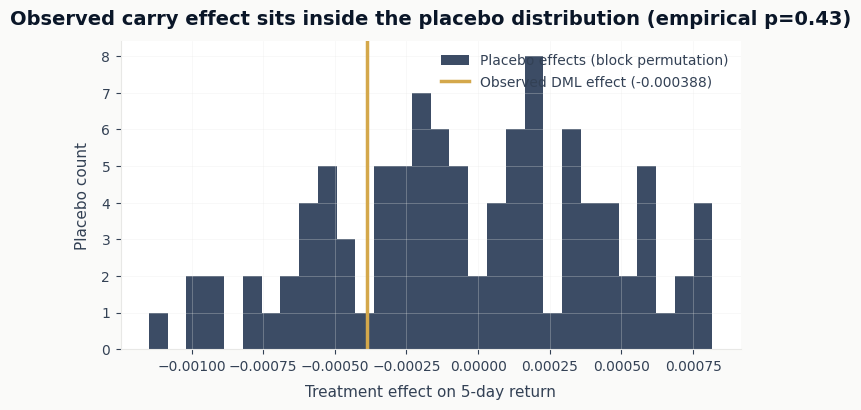

In [9]:
placebo_arr = np.array(ref.get("placebo_effects", []))
if len(placebo_arr) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(
        placebo_arr,
        bins=30,
        alpha=0.85,
        color=COLORS["slate"],
        label="Placebo effects (block permutation)",
    )
    ax.axvline(
        dml_effect,
        color=COLORS["amber"],
        linewidth=2.5,
        label=f"Observed DML effect ({dml_effect:.6f})",
    )
    ax.set_xlabel("Treatment effect on 5-day return")
    ax.set_ylabel("Placebo count")
    ax.set_title(
        f"Observed carry effect sits inside the placebo distribution "
        f"(empirical p={p_value_perm:.2f})"
    )
    ax.legend()
    fig.show()

## 5. Save Results

In [10]:

# Per-observation treatment contributions from DML residuals
T_res = dml_result.get("T_res", np.full(len(merged_clean), np.nan))
Y_res = dml_result.get("Y_res", np.full(len(merged_clean), np.nan))

# Residuals are NaN for training-only obs; align to merged_clean length
# (residuals cover the full analysis data before subsampling)
n_analysis = len(merged_clean)
if len(T_res) > n_analysis:
    # Residuals from full data; take tail matching our subsample
    T_res = T_res[-n_analysis:]
    Y_res = Y_res[-n_analysis:]

symbol_col = entity_cols[0] if entity_cols else None

predictions = pd.DataFrame(
    {
        "timestamp": pd.to_datetime(merged_clean[date_col]),
        "product": merged_clean[symbol_col].values if symbol_col else "ALL",
        "y_true": merged_clean[label_col].values,
        "treatment_value": merged_clean[TREATMENT_COL].values,
        "treatment_residual": T_res,
        "outcome_residual": Y_res,
        "treatment_contribution": T_res * dml_effect,
        "ate": dml_effect,
        "ate_se": se_hac,
    }
)

# Assemble a summary for display; the registry (causal_runs) is the SSOT.
summary = {
    "treatment": TREATMENT_COL,
    "outcome": label_col,
    "confounders": CONFOUNDER_COLS,
    "n_observations": dml_result["n_obs"],
    "naive_effect": float(naive_effect),
    "dml_effect": float(dml_effect),
    "dml_se_iid": float(dml_result["se_iid"]),
    "dml_se_hac": float(se_hac),
    "confounding_bias_pct": float(bias_pct),
    "p_value_hac": float(p_value),
    "hac_maxlags": int(results.get("hac_maxlags", 0)),
    "refutation_p_value": float(p_value_perm),
    "refutation_class": ref_class,
}

register_causal_run(
    case_study_id=CASE_STUDY_ID,
    label=PRIMARY_LABEL,
    results=results,
    predictions=predictions,
    treatment_col=TREATMENT_COL,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    notebook="11_causal_dml",
)

  -> registered causal_dml (causal_hash=fbf654a77984, p_hac=0.8313)


'fbf654a77984'

## Key Takeaways

1. **No causal evidence at the 5-day horizon**: With ratio-adjusted
   data, the DML carry effect is -0.00039 (HAC SE 0.00182, t≈-0.21,
   p=0.83), statistically indistinguishable from zero. The
   block-permutation refutation also fails (empirical p=0.43). CME is
   one of two panels in the trial where neither parametric nor
   placebo evidence supports a causal channel (alongside FX).

2. **Confounding bias percentage is misleading at small magnitudes**:
   Naive OLS gives -0.00254 and DML gives -0.00039; the -555%
   confounding-bias percentage looks dramatic but reflects a tiny
   denominator, not a strong confounding effect. Both estimates are
   small, negative, and economically indistinguishable from zero.

3. **Predictive power lives in a multi-factor model, not the direct
   effect**: on `fwd_ret_5d` only the SDF factor model clears the
   credibility line (IC +0.042, HAC CI [+0.017, +0.068], t 3.25).
   GBM (IC +0.025) and the LSTM (IC +0.004) both have HAC intervals
   that straddle zero, so neither is credited. Carry helps a working
   signal only as one input among many; its standalone causal effect
   on 5-day returns is not supported by either HAC or placebo
   evidence.

**Next**: See [`12_model_analysis`](12_model_analysis.ipynb) for the cross-family comparison.

**Book**: Section 15.6 uses CME Futures as one of two panels (with
FX) where neither parametric significance nor the block-permutation
placebo test supports a causal channel.

In [11]:
print("\n" + "=" * 60)
print(f"CHAPTER 15 RESULTS: {CASE_STUDY_ID} causal DML")
print("=" * 60)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

print(f"\n[OK] Causal DML analysis complete for {CASE_STUDY_ID}")


CHAPTER 15 RESULTS: cme_futures causal DML
  treatment: carry_pct
  outcome: fwd_ret_5d
  confounders: ['vol_21d', 'momentum_composite', 'carry_rank']
  n_observations: 41662
  naive_effect: -0.002545
  dml_effect: -0.000388
  dml_se_iid: 0.001523
  dml_se_hac: 0.001823
  confounding_bias_pct: -555.296367
  p_value_hac: 0.831280
  hac_maxlags: 34
  refutation_p_value: 0.430000
  refutation_class: Fails

[OK] Causal DML analysis complete for cme_futures
